**Why this notebook auto-reloads code**

The next cell enables IPython's `autoreload` so changes you make in the `netsci` module are picked up automatically before each cell runs, without restarting the kernel.

Reference: https://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython


In [ ]:
# Auto-reload netsci modules if code changes

%uv sync
%load_ext autoreload
%autoreload 2

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-3.0.1-cp311-cp311-win_amd64.whl.metadata (19 kB)
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 325.1 kB/s eta 0:00:01
   ---- ---------------------------------- 30.7/294.9 kB 325.1 kB/s eta 0:00:01
   ----- --------------------------------- 41.0/294.9 kB 196.9 kB/s eta 0:00:02
   ----- --------------------------------- 41.0/294.9 kB 196.9 kB/s eta 0:00:02
   ---------- ---------------------------- 81.9/294.9 kB 286.7 kB/s eta 0:00:01
   ---------- ---------------------------- 81.9/294.9 kB 286.7 kB/s eta 0:00:01
   ------------ -------------------------- 92.2/294.9 kB 261.7 kB/s eta 0:00:01
   -------------- ----------------------- 112.6/294.9 kB 273.1 kB/s eta 0:00:01
   -------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Resolved 119 packages in 3ms
Checked 116 packages in 30ms


# Week 4: Scale-Free Networks, Hubs & Resilience

**Learning objectives** — After this lab you should be able to:

- Explain why ER graphs cannot produce hubs (recap from Week 3)
- Describe preferential attachment and its role in hub formation
- Compare degree distributions of synthetic models to real networks
- Explain what "scale-free" means and why the label is debated
- Visualize power laws using CCDF and estimate exponents with MLE
- Explain the ultra-small property: why hubs compress path lengths
- Explain the Molloy-Reed criterion for giant component existence
- Demonstrate the robustness paradox: robust to random failure, fragile to targeted attack

Why do some airports have 200 routes while most have only 5? Why do a few Twitter accounts
have millions of followers? Last week we built three models — **Erdos-Renyi** for random
connectivity, **Watts-Strogatz** for clustering and short paths, and **Kleinberg** for
navigability — but none of them could explain the extreme **hubs** we see in real data. This
week we discover the mechanism that creates hubs, and we'll see why those hubs make networks
both powerful and vulnerable.

In [5]:
import networkx as nx
import numpy as np
from scipy.stats import poisson
from netsci.loaders import load_graph
from netsci.utils import SEED, graph_summary, fit_power_law
from netsci import viz, models

---
## 1. Datasets

We revisit three familiar networks this week:

- **Facebook** (334 nodes, 2,852 edges) — a dense social graph where average degree is ~17 but a few nodes have 60+ connections — and one outlier is connected to every other node. Its fat-tailed degree distribution and high clustering (C ≈ 0.68) make it the ideal test case for the BA model. *Used for: testing whether BA can reproduce real hubs.*
- **US Power Grid** (4,941 nodes, 6,594 edges) — a sparse infrastructure network where most substations connect to just 2-3 others. Its narrow degree distribution challenges every model we've seen. *Used for: contrast — what happens when hubs are absent.*
- **US Airports** (500 nodes, ~2,980 edges) — a hub-and-spoke topology where Atlanta and Chicago connect to 100+ cities while most regional airports serve fewer than 10. *Used for: the robustness experiments in Section 8, where we'll attack those hubs.*

In [6]:
G_fb = load_graph("facebook")
graph_summary(G_fb)
print()
G_pg = load_graph("powergrid")
graph_summary(G_pg)
print()
G_air = load_graph("airports")
graph_summary(G_air)

facebook: 334 nodes, 2852 edges (undirected)
Graph Summary: Graph
  Type:        undirected
  Nodes:       334
  Edges:       2852
  Density:     0.0513
  Avg degree:  17.08
  Components:  1
  Avg clustering: 0.6820

powergrid: 4941 nodes, 6594 edges (undirected)
Graph Summary: Graph
  Type:        undirected
  Nodes:       4941
  Edges:       6594
  Density:     0.0005
  Avg degree:  2.67
  Components:  1
  Avg clustering: 0.0801

airports: 500 nodes, 2980 edges (undirected)
Graph Summary: Graph
  Type:        undirected
  Nodes:       500
  Edges:       2980
  Density:     0.0239
  Avg degree:  11.92
  Components:  1
  Avg clustering: 0.6175


---
## 2. The Hub Puzzle

Back in Week 2, we measured degree distributions and noticed something striking: real networks
don't look like bell curves. The Facebook graph had a long right tail — a few nodes with
far more connections than average. We noted it but didn't explain it.

Now let's look at that tail more carefully. A **log-log plot** stretches out the high-degree
end so we can see its shape:

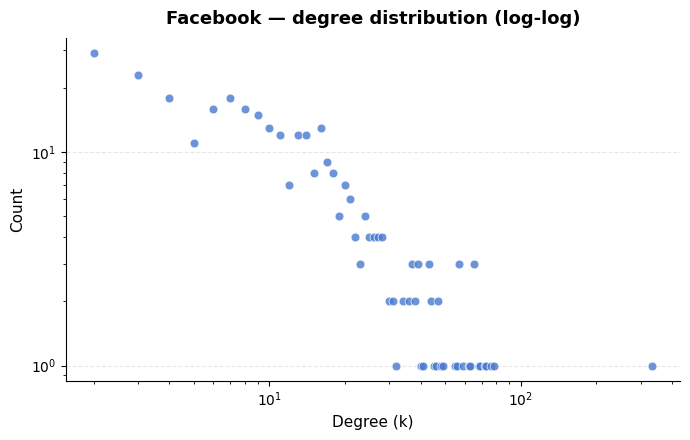

In [7]:
viz.plot_degree_dist(G_fb, log=True, title="Facebook — degree distribution (log-log)")

**Reading the plot**: Most nodes cluster at low degree (median is ~11), but the tail stretches
all the way to k = 333 — one node is literally connected to *every* other node in the graph.
Even ignoring that outlier, 18 nodes have degree above 50 — more than 3× the average. This
is a **fat-tailed** distribution: unlike a Poisson (where values beyond 2-3 standard
deviations are vanishingly rare), the probability of very high degree decays slowly. These
extreme nodes are **hubs**, and they dominate the network's structure — most shortest paths
run through them.

Can any of our models produce this? Let's find out.

---
## 3. ER & WS Recap

Last week we built three models. Let's check each one against the hub puzzle:

- **Erdos-Renyi** — edges are placed uniformly at random, so degree follows a Poisson distribution. The probability of a node having 5× the average degree is essentially zero. *No hubs.*
- **Watts-Strogatz** — starts from a regular lattice where every node has the same degree. Rewiring shuffles endpoints but barely widens the distribution. *No hubs.*
- **Kleinberg** — adds long-range links to a grid, but each node gets the same number of shortcuts. Degree stays narrow. *No hubs.*

The common thread: **none of these models assign edges based on existing degree.** A node with
100 connections is no more attractive than a node with 2. Let's see what happens when we
put ER and WS side-by-side with Facebook:

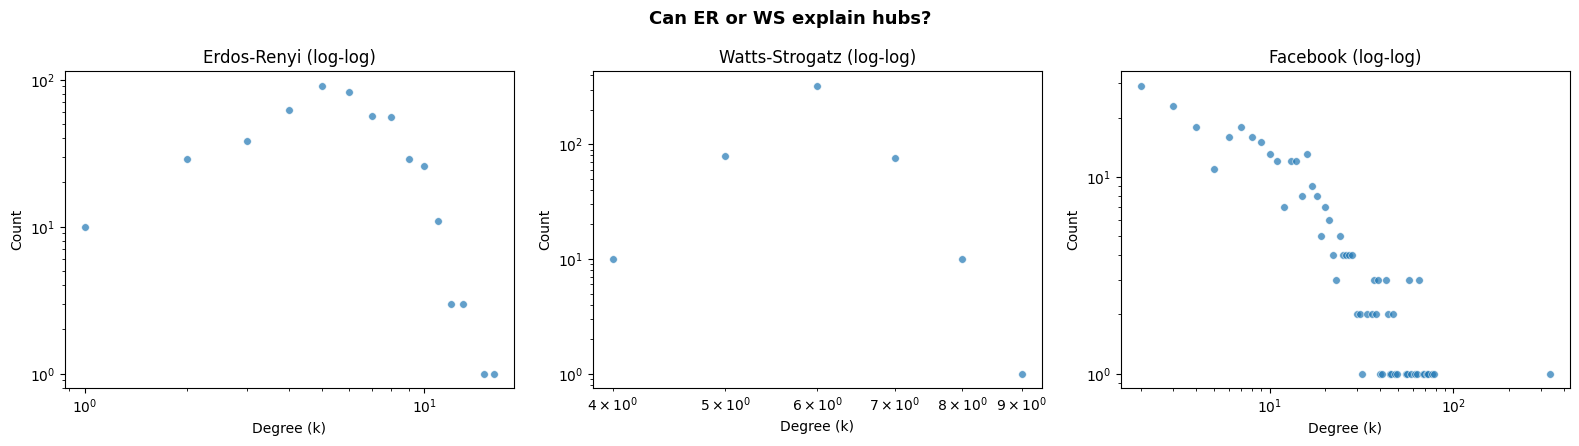

Model                Max degree Clustering
------------------------------------------
ER (n=500)                   16     0.0111
WS (n=500)                    9     0.4645
Facebook                    333     0.6820


In [8]:
# Quick recap: generate ER and WS models, compare to Facebook
G_er = models.erdos_renyi(n=500, avg_degree=6)
G_ws = models.watts_strogatz(n=500, k=6, p=0.1)

viz.plot_model_degree_comparison(
    [("Erdos-Renyi", G_er), ("Watts-Strogatz", G_ws), ("Facebook", G_fb)],
    title="Can ER or WS explain hubs?",
)

# Stats comparison
print(f"{'Model':20s} {'Max degree':>10s} {'Clustering':>10s}")
print("-" * 42)
for name, G in [("ER (n=500)", G_er), ("WS (n=500)", G_ws), ("Facebook", G_fb)]:
    max_d = max(d for _, d in G.degree())
    C = nx.average_clustering(G)
    print(f"{name:20s} {max_d:10d} {C:10.4f}")

**Reading the panels**: Look at the right edge of each distribution. ER tops out around
degree 15-16; WS is even narrower (the lattice origin keeps degrees tightly bunched around
k = 6, max ~9). Facebook, meanwhile, stretches past k = 300. On a log-log scale, ER and WS
both curve sharply downward — the exponential cutoff that kills any chance of hubs.
Facebook's points spread out along a much flatter slope (whether that's a true power law
is a question we'll test rigorously in Section 7).

The stats table confirms the mismatch: ER's max degree (~16) is about 20× smaller than
Facebook's, and ER's clustering is two orders of magnitude too low. We need a fundamentally
different mechanism — one where **popularity breeds popularity**.

---
## 4. The Barabasi-Albert Model

We've just seen that random wiring, lattice rewiring, and grid shortcuts all fail to produce
hubs. The missing ingredient? **Feedback.** In real networks, popular nodes attract even more
connections — a new paper cites well-known papers, a new user follows accounts with millions
of followers, a new airline route connects to a major hub airport.

Albert-László Barabási and Réka Albert captured this in a beautifully simple model built on
**preferential attachment** — "the rich get richer.""

The BA model rests on two simple rules:

1. **Growth** — the network starts small and new nodes arrive one at a time (unlike ER/WS, which start with all nodes present).
2. **Preferential attachment** — each new node connects to *m* existing nodes, choosing each target with probability proportional to its current degree:

$$P(\text{link to } i) = \frac{k_i}{\sum_j k_j}$$

A node with 100 connections is 50× more likely to gain the next edge than a node with 2.

The result is a **power-law** degree distribution: $P(k) \sim k^{-\gamma}$ with $\gamma \approx 3$.

**Where does γ = 3 come from?** Consider a node $i$ that joined the network at time $t_i$.
At any later time $t$ the total degree in the network is $\sum_j k_j = 2mt$ (each of the $t$
arriving nodes added $m$ edges). So the rate at which node $i$ gains new edges is:

$$\frac{\partial k_i}{\partial t} = m \cdot \frac{k_i}{2mt} = \frac{k_i}{2t}$$

This ODE gives $k_i(t) = m\sqrt{t/t_i}$: early nodes grow faster simply because they had more
time to accumulate links (*first-mover advantage*). Inverting to find the fraction of nodes
with degree $\geq k$ and differentiating yields $P(k) \sim 2m^2 k^{-3}$, i.e. **$\gamma = 3$
exactly**, independent of $m$. The exponent is not a fitting parameter — it is a direct
consequence of linear preferential attachment.

**What "scale-free" means**: Think about human heights. They follow a bell curve — the average (170 cm) is a meaningful summary, the tallest person is only ~1.4× the average, and everyone clusters within a narrow band. Height has a *characteristic scale*.

Now think about wealth. The average might be \$50K, but some people have \$50 billion — a million times more. The "average" is almost meaningless because a handful of outliers dominate. There is no typical value.

Degree in a power-law network works like wealth, not like height. In ER, the average degree is a good summary — most nodes sit close to it. In BA, the average degree might be 6 but some nodes have degree 500. If you tell someone "the average degree is 6," they'd expect a network that looks like ER. They'd be completely wrong. That absence of a meaningful "typical" degree is what **scale-free** means.

In [9]:
G_ba = models.barabasi_albert(n=500, m=3)
graph_summary(G_ba)
print(f"Max degree: {max(d for _, d in G_ba.degree())}")

Graph Summary: Graph
  Type:        undirected
  Nodes:       500
  Edges:       1491
  Density:     0.0120
  Avg degree:  5.96
  Components:  1
  Avg clustering: 0.0559
Max degree: 66


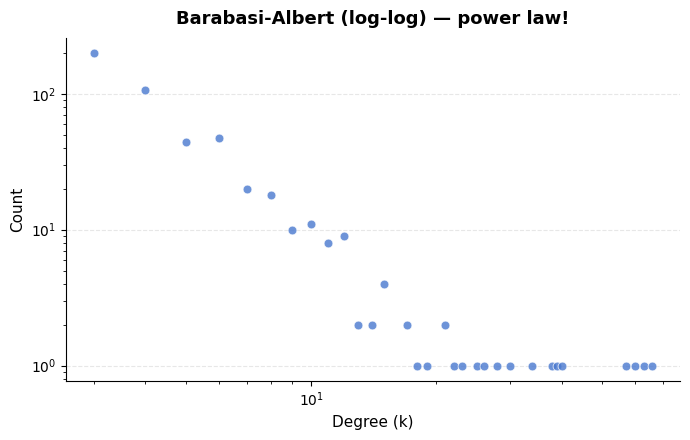

In [10]:
viz.plot_degree_dist(G_ba, log=True, title="Barabasi-Albert (log-log) — power law!")

**Reading the plot**: On the log-log scale, the BA degree distribution falls along an
approximately straight line — the signature of a power law $P(k) \sim k^{-3}$. Compare this
to the ER and WS panels from Section 3, where the points curved sharply downward. Here the
tail extends to degree 30-80 (for n=500), meaning some nodes have accumulated 10-20× the
average number of connections. These hubs emerged from nothing more than the preferential
attachment rule — no explicit "hub creation" was needed.

### Effect of *m*

The parameter *m* controls how many edges each new node adds. More edges means more
"fuel" for the rich-get-richer process.

**Try it yourself**: Generate two BA graphs with m=1 and m=5 (both n=500). Which has a
higher max degree? Does *m* change the *shape* of the distribution or just shift it?

In [11]:
# YOUR CODE HERE
G_ba_m1 = models.barabasi_albert(n=500, m=1)
G_ba_m5 = models.barabasi_albert(n=500, m=5)

max_deg_m1 = max(d for _, d in G_ba_m1.degree())
max_deg_m5 = max(d for _, d in G_ba_m5.degree())
print(
    f"BA(m=1): max degree = {max_deg_m1}, avg degree = {2 * G_ba_m1.number_of_edges() / 500:.1f}"
)
print(
    f"BA(m=5): max degree = {max_deg_m5}, avg degree = {2 * G_ba_m5.number_of_edges() / 500:.1f}"
)
print(
    "\nm=5 produces larger hubs on average because more edges feed the rich-get-richer process."
)

BA(m=1): max degree = 64, avg degree = 2.0
BA(m=5): max degree = 102, avg degree = 9.9

m=5 produces larger hubs on average because more edges feed the rich-get-richer process.


### Watching Hubs Form: Growth Snapshots

Preferential attachment is a **temporal** process — the order in which nodes arrive matters.
Early nodes have the longest time to accumulate connections, so they tend to become the
biggest hubs. The snapshots below show a BA graph at three stages of growth. Watch how
node 0 pulls ahead:

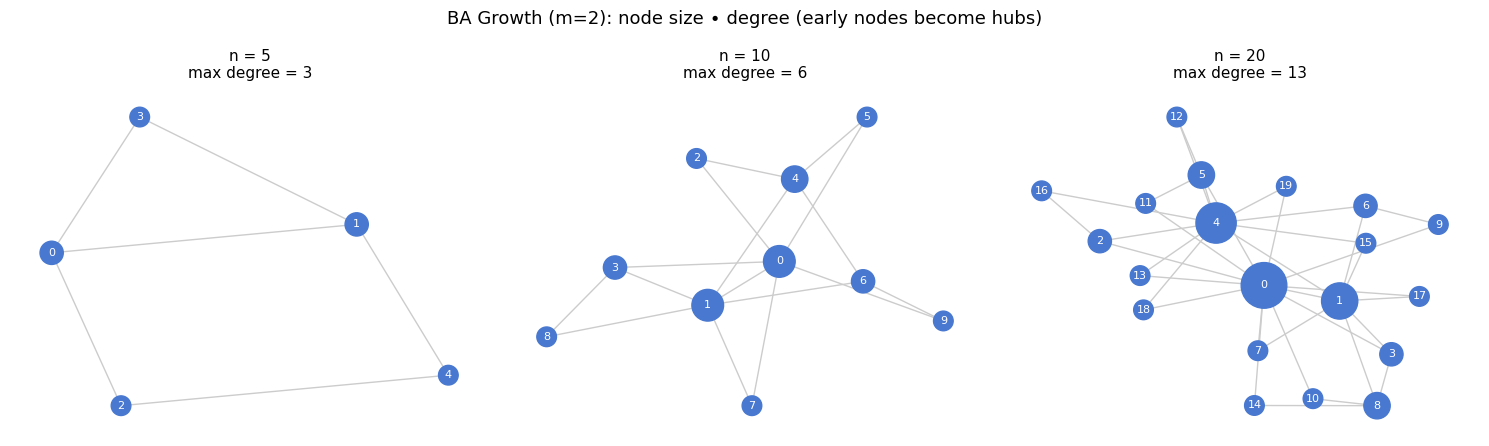

In [12]:
# BA growth snapshots: same graph at n=5, n=10, n=20
snapshots = [5, 10, 20]
G_grow = nx.barabasi_albert_graph(max(snapshots), 2, seed=SEED)
viz.plot_ba_growth(G_grow, snapshots, m=2)

**Reading the snapshots**: Even at n = 20, the first-mover advantage is visible — node 0
(which arrived first) has the largest circle. By n = 20 it has accumulated roughly twice
the connections of late arrivals. In real scale-free networks this effect is even stronger:
Google wasn't the first search engine, but it arrived early enough in the web's growth to
benefit from compounding preferential attachment.

### Interactive Exploration

You've seen that *m* shifts the distribution and that early arrival creates hubs. Now
experiment freely: change `m_tweak` below and re-run to see how hub size and distribution
shape respond.

**Predict before you tweak**: Increasing *m* means each newcomer makes more connections.
Will this increase or decrease the maximum hub degree? Will it change the *shape* of the
distribution or just shift it?

BA(n=500, m=10): max degree = 136


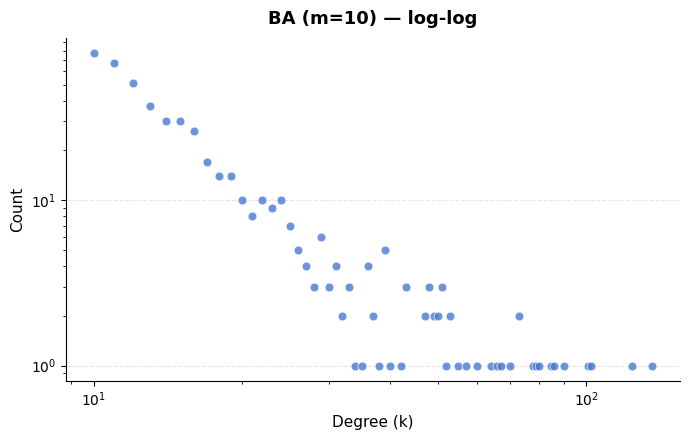

In [15]:
# ---- TWEAK: Change m in BA, observe how hub size changes ----
m_tweak = 10  # <-- change me (try 1, 3, 5, 10)

G_ba_tw = models.barabasi_albert(n=500, m=m_tweak)
max_deg = max(d for _, d in G_ba_tw.degree())
print(f"BA(n=500, m={m_tweak}): max degree = {max_deg}")
viz.plot_degree_dist(G_ba_tw, log=True, title=f"BA (m={m_tweak}) — log-log")

**What you should see**: Increasing *m* raises the average degree and shifts the entire distribution rightward, but the **power-law slope stays roughly the same** (γ ≈ 3). The maximum hub degree increases because more connections are available overall, but the relative inequality between hubs and leaves persists. The shape is governed by the preferential attachment mechanism, not by *m* alone.

---
## 5. Side-by-Side: Three Models Compared

Before we look at the data, let's summarize what each model can and can't do:

| Model | Mechanism | Captures | Misses |
|-------|-----------|----------|--------|
| **ER** | Random edges | Giant component, short paths | Clustering, hubs |
| **WS** | Lattice + rewiring | Clustering, short paths | Hubs |
| **BA** | Growth + preferential attachment | Hubs, short paths | Clustering |

The 3×3 panel below puts all three models side-by-side. Check your predictions against
the actual plots:

**Before you look**: Based on the table above, predict:
- Which model will show a **straight line** on the log-log degree plot?
- Which will have the **highest clustering**?
- Which will have the **largest max degree**?

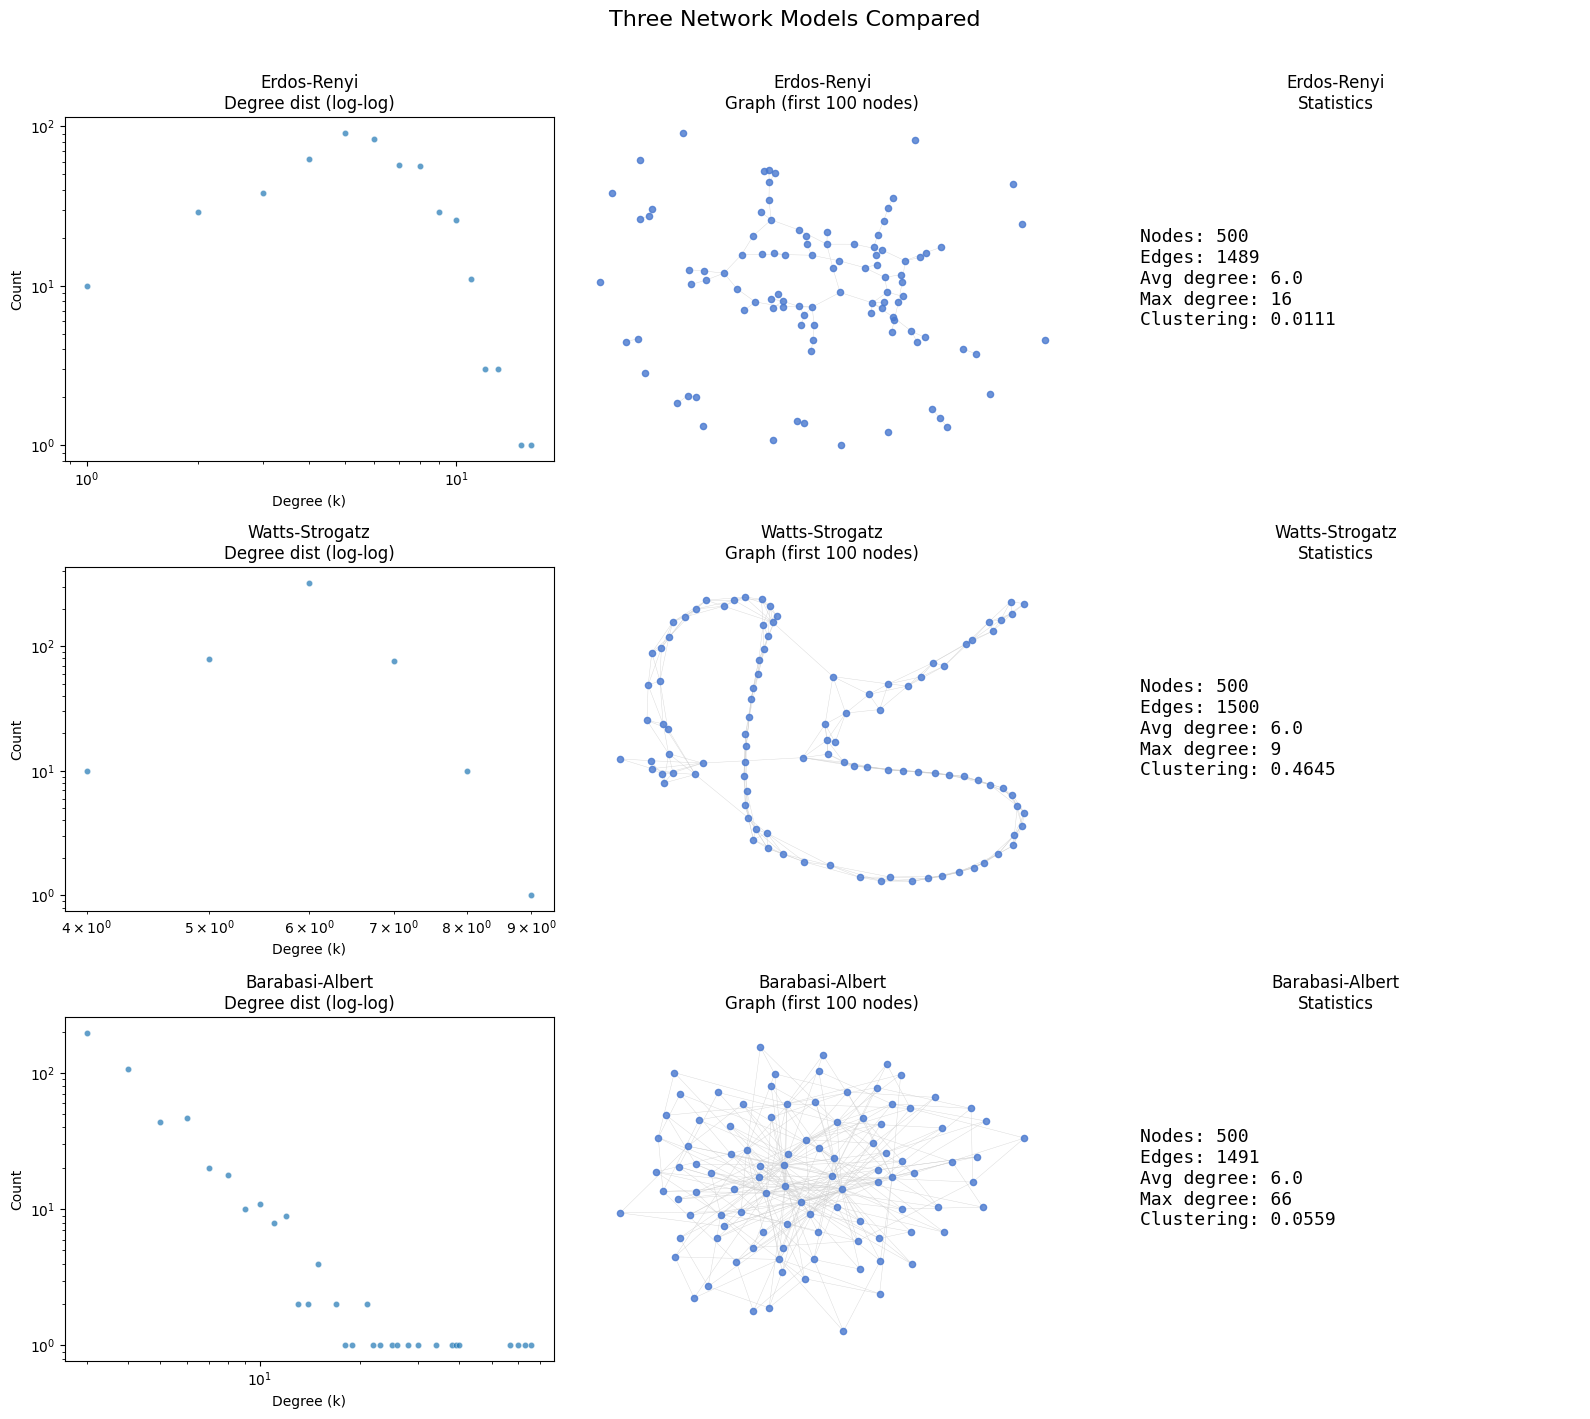

In [16]:
viz.plot_model_comparison_grid(
    [
        ("Erdos-Renyi", G_er),
        ("Watts-Strogatz", G_ws),
        ("Barabasi-Albert", G_ba),
    ]
)

**Reading the grid**: The degree-distribution column tells the story. ER's points form a
tight bell-shaped cloud (Poisson); WS is even narrower (lattice origin); BA stretches into a
long straight tail. The statistics column quantifies the trade-off: WS clustering (~0.46)
dwarfs BA (~0.06), but BA's max degree (50-70) dwarfs WS (~9).

This isn't just an implementation gap — it's a **fundamental trade-off**. Preferential
attachment concentrates edges on hubs, pulling them away from the local triangles that produce
clustering. Lattice-based models preserve local triangles but can't create hubs. No simple
two-parameter model captures both at once.

---
## 6. Model vs Reality

The 3×3 grid compared models to each other. Now let's compare to the real thing. We'll
generate a BA graph matched to Facebook: same number of nodes, and *m* chosen so the average
degree matches (avg_deg ≈ 2*m*). This is the fairest possible comparison — any remaining
gap is the model's fault, not a parameter mismatch.

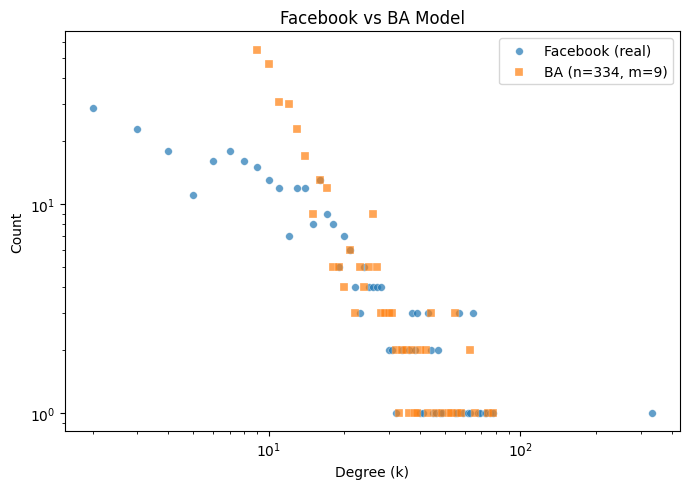

                       Facebook   BA model
Avg clustering           0.6820     0.1076
Max degree                  333         78

BA captures hubs but misses the high clustering of real social networks.


In [17]:
# Generate a BA graph with same n as Facebook
n_fb = G_fb.number_of_nodes()
avg_deg_fb = 2 * G_fb.number_of_edges() / n_fb
m_ba = max(1, round(avg_deg_fb / 2))  # BA avg_deg ≈ 2m
G_ba_fb = models.barabasi_albert(n_fb, m_ba)

viz.plot_degree_overlay(
    [
        (G_fb, "Facebook (real)", "o"),
        (G_ba_fb, f"BA (n={n_fb}, m={m_ba})", "s"),
    ],
    title="Facebook vs BA Model",
)

# Compare stats
print(f"{'':<20s} {'Facebook':>10s} {'BA model':>10s}")
print(
    f"{'Avg clustering':20s} {nx.average_clustering(G_fb):10.4f} {nx.average_clustering(G_ba_fb):10.4f}"
)
print(
    f"{'Max degree':20s} {max(d for _, d in G_fb.degree()):10d} {max(d for _, d in G_ba_fb.degree()):10d}"
)
print(f"\nBA captures hubs but misses the high clustering of real social networks.")

**Reading the overlay**: The degree distributions track each other surprisingly well in the
tail — BA reproduces Facebook's hubs. But the printed stats reveal the gap: Facebook's
clustering coefficient (~0.68) is about 6× higher than BA's (~0.11). Real social networks
have both hubs *and* tight friend-groups. BA explains the former but not the latter.

Extensions like the Holme-Kim model (which adds a triangle-closure step to PA) can partially
close this gap, but no simple growth model fully matches real social clustering. The gap
is fundamental: preferential attachment concentrates edges on hubs, pulling them away from
the local triangles that produce clustering.

### Does Preferential Attachment Actually Happen? (Intresting but not required)

Preferential attachment is a clean mathematical idea, but does it describe how real networks
grow? The empirical evidence is mixed:

- **Citation networks** — Jeong, Néda & Barabási (2003) tracked paper citations over time
  and found that highly-cited papers gain new citations at a rate proportional to their
  current count. This is almost textbook PA.
- **Internet** — Barabási, Albert & Jeong (2000) showed that new routers preferentially
  connect to high-degree nodes, consistent with hub-and-spoke growth.
- **Social networks** — the picture is messier. New users don't always seek out the most
  popular accounts; local recommendations and shared interests matter. PA is part of the
  story, but not the whole story.

The takeaway: PA is a useful *first-order* approximation, strongest in networks where
visibility correlates with connectivity (citations, web links, airline routes).

### The Ultra-Small Property

But hubs don't just affect clustering — they reshape the network's *geometry* in a
surprising way. Before we move on to testing power laws, let's look at what hubs do
to path lengths.

In Week 3 we learned that Watts-Strogatz networks are "small worlds" — rewiring a few
lattice edges into random shortcuts is enough to make average path length grow as $\ln N$.
But scale-free networks do even better.

**Shortcuts vs hubs — why the scaling differs.** In WS, each random shortcut bridges two
otherwise-distant regions of the lattice. These bridges are scattered uniformly at random,
so finding a short path means hopping from one lucky shortcut to the next — each hop roughly
halving the remaining distance, which gives the $\ln N$ scaling. In BA, high-degree hubs play
a fundamentally different role: almost every node is within a few hops of a hub, and hubs
connect directly to each other. Instead of relying on a chain of independent lucky shortcuts,
paths funnel through a small core of mega-connectors — like routing every flight through a
handful of major airports. This centralized routing is more efficient, shrinking path lengths
to $\ln N / \ln \ln N$ — the **ultra-small** property.

The difference is subtle at n=500 but becomes dramatic as networks grow. Let's measure it:

N=  200:  ER path = 3.22,  BA path = 2.83  (BA is 12% shorter)
N=  500:  ER path = 3.68,  BA path = 3.19  (BA is 13% shorter)
N= 1000:  ER path = 4.03,  BA path = 3.47  (BA is 14% shorter)
N= 2000:  ER path = 4.47,  BA path = 3.71  (BA is 17% shorter)


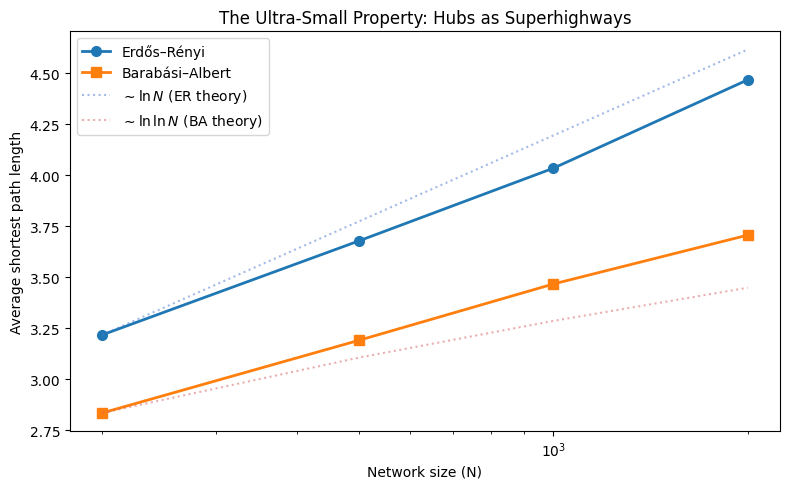

In [18]:
# Ultra-small property: average path length vs network size
sizes = [200, 500, 1000, 2000]
ultra_results = {"N": sizes, "ER": [], "BA": []}

for n in sizes:
    G_er_n = models.erdos_renyi(n=n, avg_degree=6)
    G_ba_n = models.barabasi_albert(n=n, m=3)
    # Use largest connected component for ER (may not be fully connected)
    gcc_er = G_er_n.subgraph(max(nx.connected_components(G_er_n), key=len))
    L_er = nx.average_shortest_path_length(gcc_er)
    L_ba = nx.average_shortest_path_length(G_ba_n)  # BA is always connected
    ultra_results["ER"].append(L_er)
    ultra_results["BA"].append(L_ba)
    print(
        f"N={n:5d}:  ER path = {L_er:.2f},  BA path = {L_ba:.2f}  "
        f"(BA is {100 * (1 - L_ba / L_er):.0f}% shorter)"
    )

viz.plot_ultra_small(ultra_results)

**Reading the plot**: Both curves rise with N, but BA's rises more slowly — the gap widens as
networks grow. At N=2,000, BA paths are already ~17% shorter than ER's, and the divergence
continues for larger networks. The dashed reference curves show the theoretical scaling: ER
follows $\ln N$ while BA follows $\ln N / \ln \ln N$.

Hubs act as superhighways that compress distances across the entire network. It's why you can
reach anyone on the internet in a handful of hops, and why epidemics spread faster on
scale-free networks than on random graphs. We'll see the flip side of this hub dependence
in Section 8: the same shortcuts that make the network ultra-small also make it fragile.

---
## 7. Testing for Power Laws

So far we've been eyeballing log-log plots and saying "that looks straight." But "looks
straight" is not a statistical argument. In this section we'll build up proper tools:
first a better visualization (CCDF), then a principled fitting method (MLE), and finally
a reality check (is it *really* a power law?).

### The Complementary CDF (CCDF)

The log-log scatter plots we've been using have a problem: **noisy tails**. At high degree
values, there are very few nodes, so the points scatter wildly. Binning into histograms
introduces artifacts (the result depends heavily on bin width).

The solution: the **Complementary CDF (CCDF)**, which plots $P(K \geq k)$ — the fraction of
nodes with degree *at least* k. On log-log axes:
- A **power law** → straight line with slope $-(\gamma - 1)$
- An **exponential** $e^{-k/\lambda}$ → downward-curving line (the exponent is linear in $k$, which accelerates on a log-scaled x-axis)
- A **Poisson** $e^{-\lambda}\lambda^k / k!$ → drops off even more steeply than exponential, because the $k!$ denominator kills the tail faster than any exponential term can sustain it

In practice the Poisson (ER degree distribution) and exponential look very similar on a
log-log CCDF — both curve sharply downward compared to the power law's straight line. The
key distinction is power law (straight) vs light-tailed (curving down), not Poisson vs
exponential.

The CCDF is cumulative and requires no binning, giving a much cleaner signal.

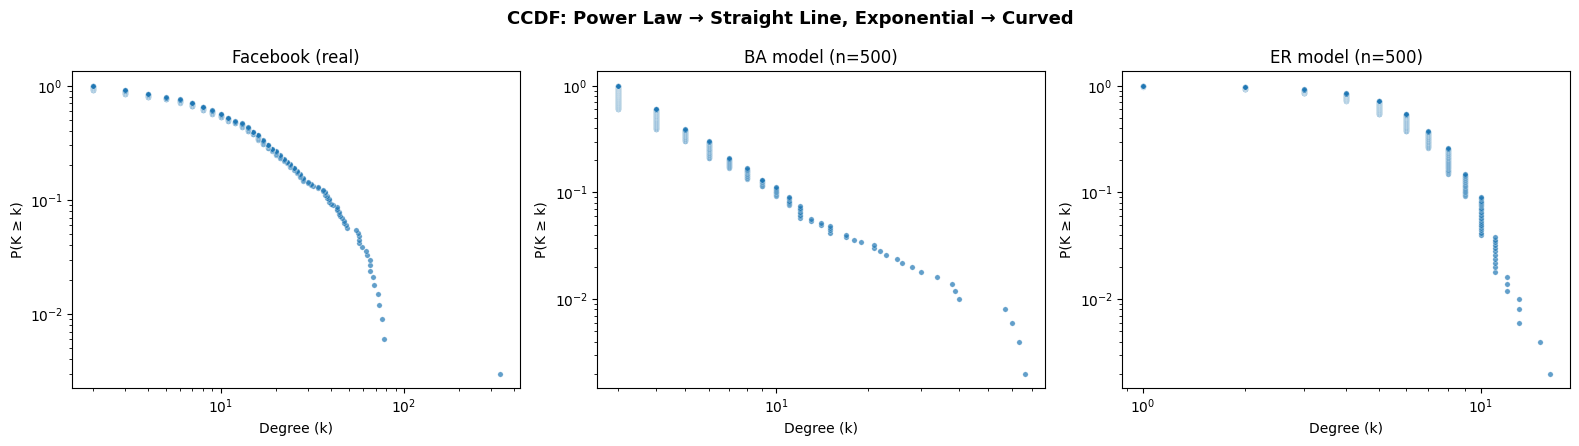

In [19]:
# CCDF comparison: Facebook vs BA vs ER
viz.plot_ccdf_panels(
    [
        ("Facebook (real)", G_fb),
        ("BA model (n=500)", G_ba),
        ("ER model (n=500)", G_er),
    ]
)

**Reading the CCDF**: BA shows a clear straight line — textbook power law. ER curves downward
sharply, confirming its exponential (Poisson) decay. Facebook sits somewhere in between: it
has a fatter tail than ER, but it's not as clean a straight line as BA. Whether Facebook's
tail is "truly" power-law or just fat-tailed is something we'll test properly in the next
subsection.

But "looks straight" is still subjective — can we put a number on it?

### Maximum Likelihood Estimation (MLE)

How do we estimate the exponent $\gamma$ of a power law $P(k) \sim k^{-\gamma}$?

**The tempting (wrong) approach — least-squares on a log-log plot.** Take the log of both
sides: $\log P(k) = -\gamma \log k + c$. That's a straight line, so just fit it with linear
regression, right? The problem is that least-squares minimizes *squared vertical residuals*,
treating every point equally. On a log-log plot the high-degree tail has very few data points,
but each one sits far from the others. These sparse, noisy points get the same weight as the
hundreds of points crowded at low $k$. The result: the fit **chases the noise in the tail**
and systematically mis-estimates $\gamma$ — typically underestimating it.

**The principled approach — MLE.** Instead of fitting a line to a transformed plot, MLE asks
a different question: *given the data I observed, which value of $\gamma$ makes that data
most probable?* It works directly with the raw degree values, not their logs, and naturally
gives more influence to the bulk of the data where the signal is strong:

$$\hat{\alpha} = 1 + n \left[ \sum_{i=1}^{n} \ln \frac{x_i}{x_{\min}} \right]^{-1}$$

where $x_i$ are the observed degree values $\geq x_{\min}$, and $n$ is the count of such
values. This closed-form estimator is consistent (converges to the true $\gamma$ as $n$
grows) and has well-understood error bounds — properties that least-squares on log-log data
lacks.

In [20]:
# Apply to Facebook, airports, and BA model
networks = [
    ("Facebook", [d for _, d in G_fb.degree()]),
    ("Airports", [d for _, d in G_air.degree()]),
    ("BA model", [d for _, d in G_ba.degree()]),
]

for name, degs in networks:
    alpha = fit_power_law(degs, k_min=2)
    print(f"{name:12s}: α = {alpha:.2f}  (γ = α ≈ {alpha:.1f})")

print(
    "\nNote: BA theory predicts γ = 3.0 for large N (finite-size effects lower the estimate)."
)
print("Small α means a heavier tail — more probability mass in the hubs.")

Facebook    : α = 1.59  (γ = α ≈ 1.6)
Airports    : α = 1.88  (γ = α ≈ 1.9)
BA model    : α = 2.17  (γ = α ≈ 2.2)

Note: BA theory predicts γ = 3.0 for large N (finite-size effects lower the estimate).
Small α means a heavier tail — more probability mass in the hubs.


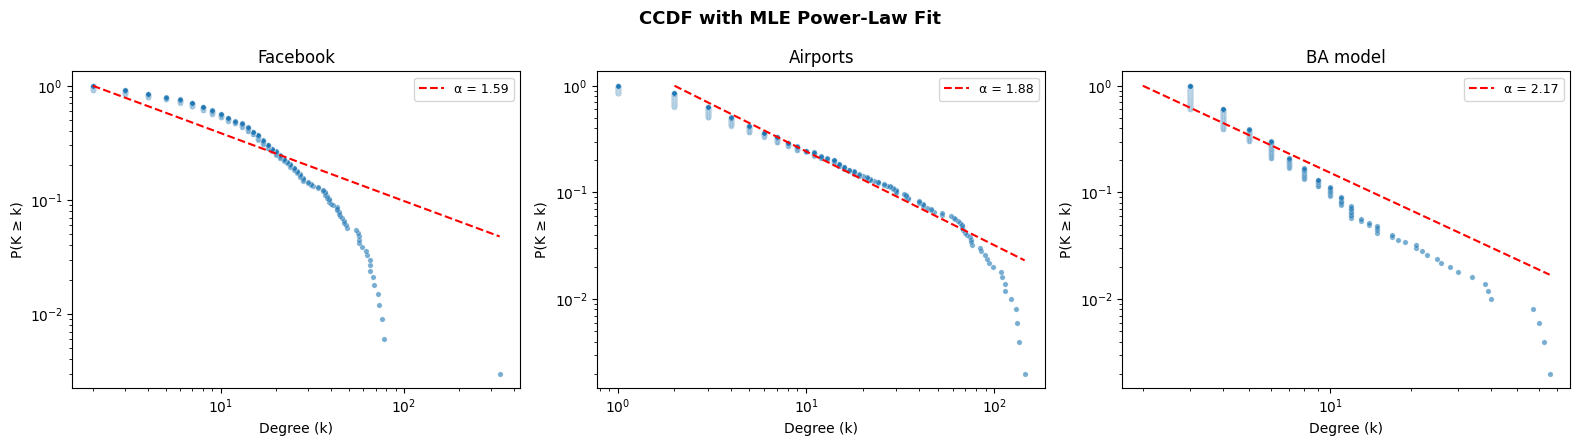

In [21]:
# Show MLE fit line on CCDF for all three
viz.plot_ccdf_mle_panels(networks, fit_power_law)

**Interpreting the exponents**: The BA theory predicts γ = 3.0 for large networks, but our
n=500 graph gives α ≈ 2.2 — finite-size effects shift the estimate downward. Real networks
(Facebook α ≈ 1.6, airports α ≈ 1.9) show even smaller exponents, reflecting growth
mechanisms more complex than pure preferential attachment.

But having a well-fitting exponent doesn't prove the distribution *is* actually a power law.
A log-normal can look just as straight over a limited range. How do we tell them apart?

### Is It Really a Power Law?

Many networks *look* like power laws on a log-log plot, but are they really? Let's put the
airports network — our clearest hub-and-spoke example — against three theoretical candidates:

1. **Power law**: $P(k) \sim k^{-\gamma}$ — straight line on CCDF
2. **Exponential**: $P(k) \sim e^{-k/\lambda}$ — the ER/Poisson tail
3. **Log-normal**: $P(k) \sim (1/k) \cdot e^{-(\ln k - \mu)^2 / 2\sigma^2}$ — often confused with power laws

**What is a log-normal?** A variable is log-normal when its *logarithm* is normally
distributed. Think of a process where many small, independent *multiplicative* factors
combine (e.g., a paper's citation count depends on visibility × topic popularity × timing ×
author reputation × …). By the central limit theorem the product of many independent factors
has a log that is approximately normal — hence log-normal. The resulting distribution is
right-skewed with a fat-ish tail that looks deceptively straight on a log-log plot over a
limited range, but eventually curves downward faster than a true power law.

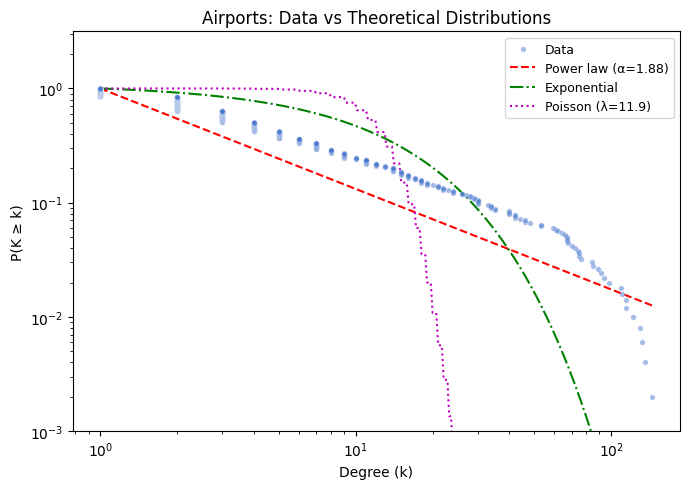

In [22]:
# Compare airports CCDF to theoretical distributions
viz.plot_ccdf_vs_theory(
    G_air,
    fit_power_law,
    poisson.cdf,
    title="Airports: Data vs Theoretical Distributions",
)

**What the comparison shows**: The exponential and Poisson curves drop to zero well before
k = 80, yet the airports data still has 3% of nodes above that degree. The power-law fit
tracks this fat tail — it's the only candidate that stays in the right ballpark at high k.
The fit isn't perfect (the power law slightly overshoots beyond k = 100), but it's far
closer than the alternatives.

Note that not every network passes this test. Our small Facebook ego-graph (n=334), for
instance, is actually fit *better* by an exponential — its one extreme outlier (k=333) skews
the MLE, and the rest of the distribution decays quickly. This is exactly the kind of trap
that rigorous testing catches.

The key message: **proper methodology matters**. Clauset, Shalizi & Newman (2009) showed that
many "scale-free" claims in the literature don't survive rigorous statistical testing.

### The Scale-Free Debate (Intresting but not required)

Broido & Clauset (2019) applied rigorous statistical tests to over
1,000 real networks and found that fewer than 5% showed strong evidence for a power-law degree
distribution. Their conclusion was provocative: "scale-free networks are rare."

Barabási and collaborators pushed back, arguing that the test criteria were too strict — many
networks show *approximate* power-law behavior over a meaningful range of degrees, even if
they fail a strict goodness-of-fit test. The preferential attachment mechanism is real (we saw
the citation evidence in Section 6), and the resulting fat tails have practical consequences
for robustness and spreading, even if the tail isn't a mathematically perfect power law.

**Practical takeaway**: Don't get hung up on whether a network is "truly" scale-free. The
important question is whether the degree distribution is fat-tailed enough that hubs dominate
the network's behavior — and for that, CCDF + MLE gives you the evidence you need.

---
## 8. Network Robustness

Think about a snowstorm that shuts down a random regional airport — say, Wichita. A few
hundred travelers are inconvenienced, but the rest of the network barely notices. Now imagine
the same storm hits Atlanta, the nation's busiest hub. Suddenly thousands of connecting flights
are grounded, and the cascade ripples across the entire system.

This is the **robustness paradox**: the same hubs that make scale-free networks efficient
(short paths, high connectivity) also make them **fragile to targeted attack**. Remove nodes
at random and you'll almost always hit low-degree "leaves" that nobody depends on. But remove
the hubs deliberately and the network falls apart.

How do we make this precise?

### The Molloy-Reed Criterion

The giant component exists as long as:

$$\frac{\langle k^2 \rangle}{\langle k \rangle} > 2$$

where $\langle k \rangle$ is the average degree and $\langle k^2 \rangle$ is the average squared
degree. The $\langle k^2 \rangle$ term is dominated by hubs — nodes with degree 100 contribute
$100^2 = 10{,}000$ to the average, while typical nodes contribute just $5^2 = 25$. So the
hubs are literally holding the giant component together. Remove them and $\langle k^2 \rangle$
plummets, the ratio drops below 2, and the network shatters.

In [78]:
# Compute Molloy-Reed criterion for our networks
for name, G in [("Airports", G_air), ("Facebook", G_fb), ("Power Grid", G_pg)]:
    degrees = [d for _, d in G.degree()]
    k_avg = np.mean(degrees)
    k2_avg = np.mean(np.array(degrees) ** 2)
    kappa = k2_avg / k_avg
    print(f"{name:12s}: ⟨k⟩ = {k_avg:.1f},  ⟨k²⟩/⟨k⟩ = {kappa:.1f}  (threshold = 2)")
    print(f"{"":<12s}  Giant component {"EXISTS" if kappa > 2 else "DOES NOT EXIST"}")
    print()

print("The higher ⟨k²⟩/⟨k⟩ is above 2, the more resilient the network.")
print(
    "Fat-tailed networks (airports) have very high ⟨k²⟩, making them robust to random failure."
)

Airports    : ⟨k⟩ = 11.9,  ⟨k²⟩/⟨k⟩ = 53.8  (threshold = 2)
              Giant component EXISTS

Facebook    : ⟨k⟩ = 17.1,  ⟨k²⟩/⟨k⟩ = 48.7  (threshold = 2)
              Giant component EXISTS

Power Grid  : ⟨k⟩ = 2.7,  ⟨k²⟩/⟨k⟩ = 3.9  (threshold = 2)
              Giant component EXISTS

The higher ⟨k²⟩/⟨k⟩ is above 2, the more resilient the network.
Fat-tailed networks (airports) have very high ⟨k²⟩, making them robust to random failure.


**Reading the numbers**: Airports and Facebook both have ⟨k²⟩/⟨k⟩ around 50 — far above the
threshold of 2. Their hubs pump up ⟨k²⟩ enormously, making the giant component very robust
(you'd have to remove a lot to bring the ratio down). The power grid, by contrast, sits at
~3.9 — barely above 2. Without hubs to inflate ⟨k²⟩, it's already close to the fragmentation
threshold. Even modest random failures could push it over the edge.

**Predict before you run**: If we remove nodes randomly vs removing the highest-degree nodes first, which strategy will destroy the giant component faster? Think about what happens to ⟨k²⟩/⟨k⟩ in each case.

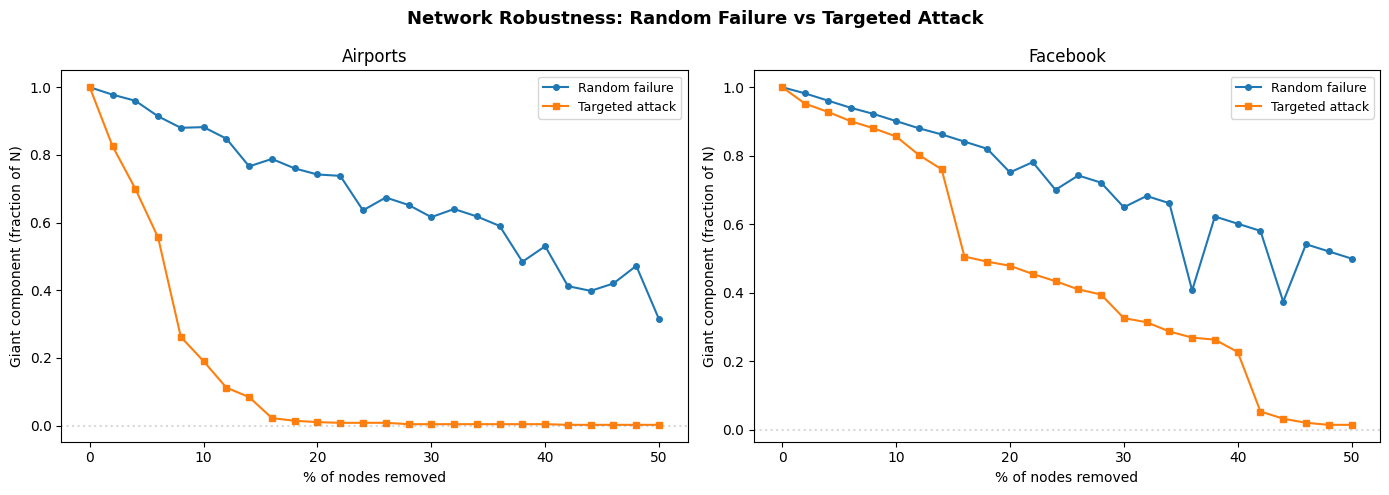

In [79]:
# Random vs targeted attack sweep — track giant component size
fractions = np.arange(0, 0.51, 0.02)
rng_robust = np.random.default_rng(SEED)

results_robust = {}
for name, G in [("Airports", G_air), ("Facebook", G_fb)]:
    gcc_random = []
    gcc_targeted = []
    nodes = list(G.nodes())
    N = len(nodes)

    for f in fractions:
        n_remove = int(N * f)

        # Random removal
        G_rand = G.copy()
        remove_rand = set(rng_robust.choice(nodes, size=n_remove, replace=False))
        G_rand.remove_nodes_from(remove_rand)
        if G_rand.number_of_nodes() > 0:
            gcc_rand = len(max(nx.connected_components(G_rand), key=len)) / N
        else:
            gcc_rand = 0
        gcc_random.append(gcc_rand)

        # Targeted removal (highest degree first, recalculated)
        G_targ = G.copy()
        for _ in range(n_remove):
            if G_targ.number_of_nodes() == 0:
                break
            top_node = max(G_targ.nodes(), key=lambda n: G_targ.degree(n))
            G_targ.remove_node(top_node)
        if G_targ.number_of_nodes() > 0:
            gcc_targ = len(max(nx.connected_components(G_targ), key=len)) / N
        else:
            gcc_targ = 0
        gcc_targeted.append(gcc_targ)

    results_robust[name] = (gcc_random, gcc_targeted)

viz.plot_robustness_sweep(results_robust, fractions)

**The robustness paradox**: Scale-free networks (like airports) are remarkably **robust to random failure** — you can remove 30-40% of nodes randomly and the giant component barely shrinks. But they are **fragile to targeted attack** — removing just 10-15% of the highest-degree hubs shatters the network.

**The mathematical reason**: Random removal barely changes ⟨k²⟩/⟨k⟩ because most removed nodes are low-degree (the vast majority in a power-law distribution). But removing hubs destroys the high-k² terms that keep the ratio above 2.

This paradox has profound implications: the same hub structure that makes scale-free networks efficient also makes them vulnerable to deliberate attack.

### Visualizing the Damage

The sweep plot showed the numbers. Let's see what the network *looks like* after random vs
targeted removal:

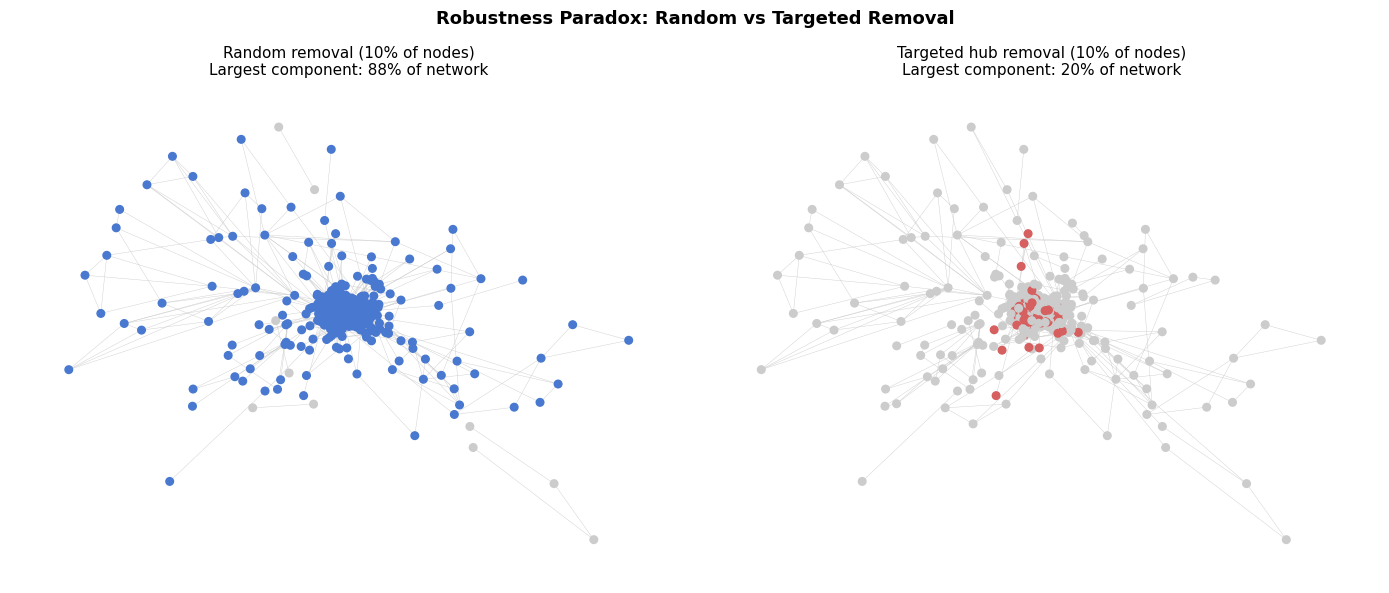

In [80]:
# Immunization concept: random removal vs targeted hub removal
viz.plot_robustness_concept(G_air, frac_remove=0.10)

**The hub removal effect**: Removing 10% of nodes at random (left) barely dents the network — the giant component remains mostly intact. But removing the top 10% highest-degree hubs (right) shatters it into disconnected fragments. This asymmetry is why targeted attacks on infrastructure networks (power grids, internet backbone) are so dangerous — and why understanding hubs matters for network defense.

---
## Summary

| Model | Degree dist | Clustering | Hubs? | Path length | Key mechanism |
|-------|------------|-----------|-------|-------------|---------------|
| **Erdos-Renyi** | Poisson (narrow) | Low | No | ~ ln N | Random edges |
| **Watts-Strogatz** | Narrow (near-uniform) | High | No | ~ ln N | Rewired lattice |
| **Barabasi-Albert** | Power law (fat tail) | Low | Yes | ~ ln N / ln ln N | Preferential attachment |

### Analysis Methods

| Method | Purpose | Key insight |
|--------|---------|-------------|
| **CCDF plot** | Visualize degree distributions cleanly | No binning artifacts; power law = straight line |
| **MLE fitting** | Estimate power-law exponent | Statistically principled; avoids log-log regression bias |
| **Distribution comparison** | Test "is it really a power law?" | Compare power law vs exponential vs Poisson |
| **Molloy-Reed criterion** | Test giant component existence | ⟨k²⟩/⟨k⟩ > 2 for connected network |
| **Robustness paradox** | Targeted vs random failure | Hubs = robust to random, fragile to targeted |

No single model captures everything about real networks. BA explains hubs but misses
clustering. WS explains clustering but misses hubs. The hubs that make scale-free networks
ultra-small and efficient also make them vulnerable to targeted attack — a fundamental
trade-off with no free lunch.

**What comes next**: Week 5 takes us to **Community Detection** — finding tightly-knit groups
within networks. BA's inability to produce clustering means it also can't produce community
structure — so we'll need new tools to identify and understand the groups that real networks
naturally form.